グレースケール画像 $x[n_1, n_2]$ に対し，
振幅スケーリング・オフセット $y[n_1, n_2] = a \cdot x[n_1, n_2] + b$ を利用して，
以下の画像を生成し，元の画像と並べて表示しなさい．

- ネガ画像（$a = -1, b = 255$）
- 明るさを上げた画像（$a = 1, b = 50$）
- コントラストを上げた画像（$y = 1.5 (x - 128) + 128$）
ただし，uint8 型のまま計算するとオーバーフロー等が起きるため，
一度 float64 型に変換してから計算し，最後に区間 $[0, 255]$ にクリップして uint8 型に戻すこと．

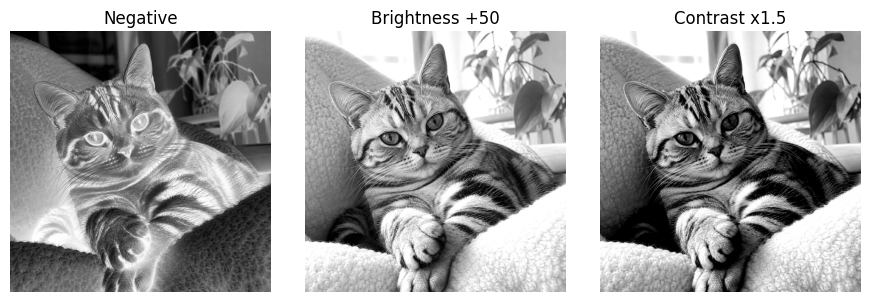

In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

x = Image.open('/home/syamashita/initial-training-2026/syamashita-tu/chapter12/cat.png')
x = x.convert('L')

x_array = np.array(x)

# 計算用に型を変換
x_calc = x_array.astype(np.float64)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

# 白黒反転
y_array = -1 * x_calc + 255
y_array = np.clip(y_array, 0, 255).astype(np.uint8)
ax[0].imshow(y_array, cmap='gray')
ax[0].set_title('Negative')
ax[0].axis('off')

# 明るくする
y_array = x_calc + 50
y_array = np.clip(y_array, 0, 255).astype(np.uint8)
ax[1].imshow(y_array, cmap='gray')
ax[1].set_title('Brightness +50')
ax[1].axis('off')

# コントラスト強調
y_array = 1.5 * (x_calc - 128) + 128
y_array = np.clip(y_array, 0, 255).astype(np.uint8)
ax[2].imshow(y_array, cmap='gray')
ax[2].set_title('Contrast x1.5')
ax[2].axis('off')

plt.tight_layout()
plt.show()